# MercyHealth cold-chain — digging through 90 days of shipments

Dana's question, basically: *where are we actually losing product or risking compliance,
and where are we fine — what should I be watching?*

So this is me poking at the export until it tells me something. I want to (a) trust the
data before I trust any conclusion, (b) try the obvious explanations and see if they hold
up, and (c) come out with a couple of things I'd actually bet a recommendation on — plus
a rough dollar figure so it's not all percentages.

Runs top to bottom. Only thing to set is the `CSV` path.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from scipy import stats
    HAVE_SCIPY = True
except ImportError:
    HAVE_SCIPY = False  # p-values just get skipped, notebook still runs

pd.set_option("display.width", 130)
plt.rcParams["figure.figsize"] = (8, 4)

# --- set this to wherever the export lives ---
CSV = "mercyhealth_shipments_90d - mercyhealth_shipments_90d.csv.csv"
for cand in (Path(CSV), Path("..") / CSV):   # works from repo root or analysis/
    if Path(cand).exists():
        CSV = Path(cand); break

df = pd.read_csv(CSV)
print(df.shape)
df.head()

(252, 16)


,shipment_id,ship_date,origin_dc,destination_city,destination_state,destination_region,carrier,service_level,temp_class,planned_delivery,actual_delivery,min_temp_c,max_temp_c,excursion_minutes,recipient_issue,issue_type
0,MH-20260128-1220,2026-01-28 8:45,"Memphis, TN",San Francisco,CA,West,UPS,Next Day Air,2-8C,2026-01-29 4:45,2026-01-29 3:27,3.2,6.6,0,N,NaN
1,MH-20260128-1107,2026-01-28 23:15,"Reno, NV",Salt Lake City,UT,Mountain,FedEx,Priority Overnight,2-8C,2026-01-29 17:15,2026-01-29 15:51,3.6,6.2,0,N,NaN
2,MH-20260129-1169,2026-01-29 4:30,"Memphis, TN",Philadelphia,PA,East,FedEx,2Day,CRT,2026-01-31 0:30,2026-01-31 1:54,18.2,25.7,0,N,NaN
3,MH-20260129-1113,2026-01-29 4:45,"Allentown, PA",Houston,TX,South,FedEx,Priority Overnight,2-8C,2026-01-29 22:45,2026-01-29 22:51,3.7,7.5,0,Y,damaged_packaging
4,MH-20260129-1164,2026-01-29 8:45,"Memphis, TN",Miami,FL,South,FedEx,Priority Overnight,2-8C,2026-01-30 2:45,2026-01-30 12:21,2.8,7.1,0,N,NaN


In [2]:
# just eyeballing types + ranges before anything else
df.describe(include="all").T[["count", "unique", "top", "freq"]]

,count,unique,top,freq
shipment_id,252,252,MH-20260128-1220,1
ship_date,252,248,2026-02-07 21:30,2
origin_dc,252,3,"Memphis, TN",121
destination_city,252,23,New York,25
destination_state,252,19,CA,47
destination_region,252,5,West,71
carrier,252,3,FedEx,145
service_level,252,8,Priority Overnight,101
temp_class,252,3,2-8C,131
planned_delivery,252,250,2026-02-08 15:30,2


### the columns, and what each one actually means for us

| field | what it is | why I care |
|---|---|---|
| `shipment_id` | unique key | dedupe / join |
| `ship_date` | left the DC | trend, day-of-week, etc. |
| `origin_dc` | which DC | is one DC the problem? |
| `destination_city/state/region` | where it's going | lane analysis |
| `carrier` | FedEx / UPS / OnTrac | who's moving it |
| `service_level` | speed tier bought | are we paying for speed we don't get? |
| `temp_class` | required range: **2-8C** fridge, **CRT** room temp, **Frozen** | different products fail differently |
| `planned_delivery` / `actual_delivery` | promised vs actual | on-time |
| `min_temp_c` / `max_temp_c` | coldest/hottest the in-box sensor saw | did it stay in range |
| `excursion_minutes` | minutes outside the allowed band | how bad the breach was |
| `recipient_issue` Y/N | did the pharmacy complain | our only "did it actually go wrong" signal |
| `issue_type` | damaged / temp / late / missing docs | what they complained about |

The two I keep coming back to: `excursion_minutes` (did it go out of temp) and
`recipient_issue` (did anyone downstream notice). Most of this is really about how those
two relate.

## 1. do I even trust this data?

`excursion_minutes` was computed by someone against thresholds I wasn't handed. Not
touching any conclusions until I've checked the basics and figured out those rules.

In [3]:
print("rows:", len(df), " unique ids:", df.shipment_id.nunique())
df.isna().sum()[df.isna().sum() > 0]

rows: 252  unique ids: 252


actual_delivery      2
issue_type         231
dtype: int64

In [4]:
# issue_type blank == no issue, that's fine. but 2 missing actual_delivery — look, don't assume
df[df.actual_delivery.isna()][["shipment_id","ship_date","carrier","temp_class","planned_delivery"]]

,shipment_id,ship_date,carrier,temp_class,planned_delivery
250,MH-20260427-1039,2026-04-27 10:45,FedEx,2-8C,2026-04-28 4:45
251,MH-20260427-1084,2026-04-27 13:30,FedEx,Frozen,2026-04-28 7:30


Both shipped on the last `ship_date` in the file and were due the next day → almost
certainly still in transit when this was pulled. Keeping them for temperature, dropping
them from on-time math later (no actual arrival yet).

In [5]:
# physical sanity: a sensor's min can't exceed its max
print("impossible rows (min>max):", (df.min_temp_c > df.max_temp_c).sum())

# dupe check the lazy way first...
# print(df.shipment_id.value_counts().head())   # all 1, fine, moving on

impossible rows (min>max): 0


### reverse-engineering the temperature bands

I don't actually know what thresholds `excursion_minutes` was scored against. But I can
recover them: rows flagged as excursions should sit *outside* the band, clean rows
*inside* it. This also settles which CRT definition they used — there are two common ones
(tight 20–25 °C vs loose 15–30 °C) and it matters a lot which.

In [6]:
# first pass — just look at the temp ranges of clean vs flagged per class
for tc, g in df.groupby("temp_class"):
    clean, flag = g[g.excursion_minutes == 0], g[g.excursion_minutes > 0]
    print(f"{tc:7} clean: min[{clean.min_temp_c.min()},{clean.min_temp_c.max()}] "
          f"max[{clean.max_temp_c.min()},{clean.max_temp_c.max()}]   "
          f"flagged: min[{flag.min_temp_c.min()},{flag.min_temp_c.max()}] "
          f"max[{flag.max_temp_c.min()},{flag.max_temp_c.max()}]")

2-8C    clean: min[2.2,4.1] max[6.1,7.5]   flagged: min[-0.7,3.8] max[6.9,12.8]
CRT     clean: min[16.9,19.8] max[23.6,27.7]   flagged: min[10.4,18.4] max[25.3,36.6]
Frozen  clean: min[-23.8,-21.7] max[-18.1,-16.0]   flagged: min[-25.0,-22.0] max[-12.2,-7.2]


In [7]:
# ok that's suggestive but let me actually test candidate bands properly.
# a band is "right" if no clean row falls outside it AND no flagged row sits fully inside it.
def test_band(tc, lo, hi):
    g = df[df.temp_class == tc]
    clean_out = ((g.excursion_minutes == 0) & ((g.min_temp_c < lo) | (g.max_temp_c > hi))).sum()
    flag_in   = ((g.excursion_minutes > 0) & (g.min_temp_c >= lo) & (g.max_temp_c <= hi)).sum()
    flag = "  <-- consistent" if clean_out == 0 and flag_in == 0 else ""
    print(f"{tc:7} [{lo:>4},{hi:>3}]  clean-outside={clean_out:2d}  flagged-inside={flag_in:2d}{flag}")

test_band("2-8C", 2, 8)
test_band("CRT", 20, 25)    # tight USP nominal
test_band("CRT", 15, 30)    # loose USP transport band
test_band("Frozen", -90, -10)
test_band("Frozen", -90, -15)

2-8C    [   2,  8]  clean-outside= 0  flagged-inside= 0  <-- consistent
CRT     [  20, 25]  clean-outside=71  flagged-inside= 0
CRT     [  15, 30]  clean-outside= 0  flagged-inside= 0  <-- consistent
Frozen  [ -90,-10]  clean-outside= 0  flagged-inside= 3
Frozen  [ -90,-15]  clean-outside= 0  flagged-inside= 0  <-- consistent


Good — now I know what I'm working with:

- **2–8 °C** → scored against 2–8. no surprise.
- **CRT** → it's the **loose 15–30** band, not 20–25. the tight band would call 71 totally
  normal room-temp shipments "excursions," so they (correctly imo) used the transport band.
  alerting every time a truck drifts a couple degrees would just be noise.
- **Frozen** → scored *stricter* than "just stay below −10." the real ceiling is around
  **−15 °C** (hottest clean frozen max is −16.0, coldest flagged is −12.2). worth confirming
  the exact frozen spec, but it's internally consistent.

`excursion_minutes` checks out. on with it.

## 2. lay of the land — where are the excursions?

In [8]:
df["has_exc"] = df.excursion_minutes > 0
df["issue"]   = df.recipient_issue.eq("Y")

print("overall: %.0f%% of shipments had an excursion (%d/%d), %.0f total hours out of temp\n"
      % (df.has_exc.mean()*100, df.has_exc.sum(), len(df), df.excursion_minutes.sum()/60))

for col in ["carrier", "temp_class"]:
    t = df.groupby(col).agg(n=("has_exc","size"), exc_rate=("has_exc","mean"),
                            avg_min=("excursion_minutes","mean"))
    t["exc_rate"] = (t.exc_rate*100).round(0); t["avg_min"] = t.avg_min.round(0)
    print(t.sort_values("exc_rate", ascending=False).to_string(), "\n")

overall: 19% of shipments had an excursion (48/252), 244 total hours out of temp

           n  exc_rate  avg_min
carrier                        
OnTrac    38      47.0    233.0
FedEx    145      14.0     25.0
UPS       69      14.0     31.0 

              n  exc_rate  avg_min
temp_class                        
Frozen       45      33.0    176.0
2-8C        131      21.0     42.0
CRT          76       7.0     15.0 



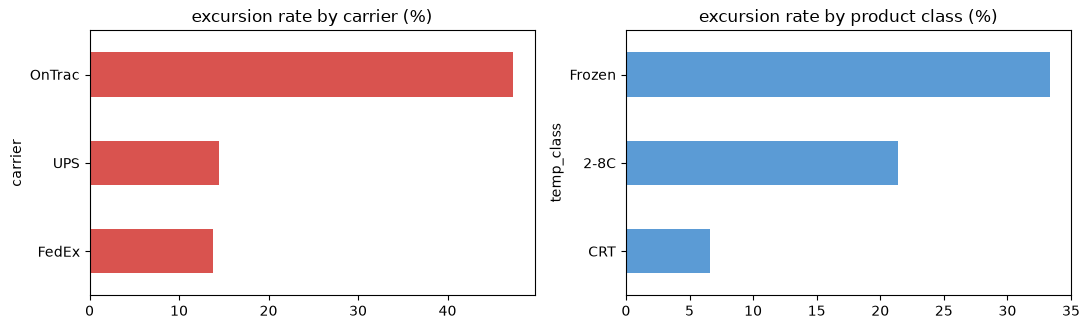

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
(df.groupby("carrier").has_exc.mean()*100).sort_values().plot.barh(ax=ax[0], color="#d9534f")
ax[0].set_title("excursion rate by carrier (%)")
(df.groupby("temp_class").has_exc.mean()*100).sort_values().plot.barh(ax=ax[1], color="#5b9bd5")
ax[1].set_title("excursion rate by product class (%)")
plt.tight_layout(); plt.show()

Two things, and one's already a surprise:

- OnTrac's excursion rate is ~3× FedEx/UPS.
- **CRT (room temp) is the *safest* class, not 2–8C.** I'd genuinely have guessed
  refrigerated was our hardest problem. nope — frozen's the worst and room-temp basically
  takes care of itself.

before I pin it on OnTrac though — maybe OnTrac just gets the hard lanes or hard products.
let me try to explain the excursions *without* blaming the carrier.

## 3. testing the explanations I'd reach for first

**Hypothesis A: "it's the lanes — long hot West/South routes run warm."**

In [10]:
(df.groupby("destination_region").has_exc.mean()*100).round(0).sort_values(ascending=False)

destination_region
West        30.0
South       20.0
Midwest     16.0
East        13.0
Mountain     4.0
Name: has_exc, dtype: float64

West's the worst by a lot, which *looks* like it backs the lane theory. but rate alone
can't tell me if it's the region or who drives it. who actually operates each region?

In [11]:
(pd.crosstab(df.destination_region, df.carrier, normalize="index")*100).round(0)

carrier,FedEx,OnTrac,UPS
destination_region,,,
East,64.0,0.0,36.0
Midwest,71.0,0.0,29.0
Mountain,57.0,0.0,43.0
South,71.0,0.0,29.0
West,34.0,54.0,13.0


there it is — **OnTrac only runs the West** (and nowhere else). so "West is risky" and
"OnTrac is risky" are completely tangled. the honest test: hold carrier constant.

carrier             FedEx  OnTrac   UPS
destination_region                     
East                 15.0     NaN   9.0
Midwest              14.0     NaN  22.0
Mountain              0.0     NaN  10.0
South                19.0     NaN  21.0
West                  8.0    47.0  11.0


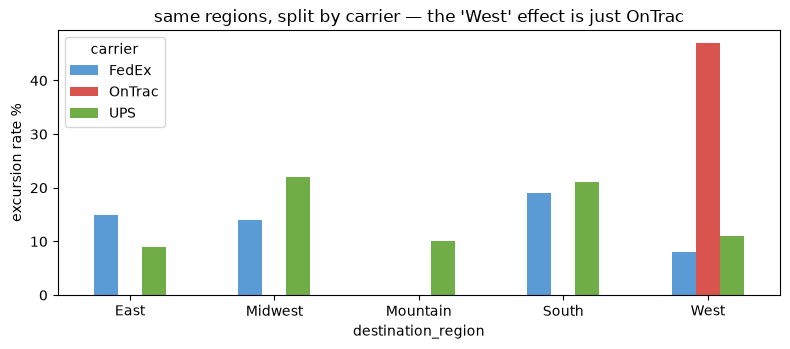

In [12]:
strat = (df.pivot_table(index="destination_region", columns="carrier",
                        values="has_exc", aggfunc="mean")*100).round(0)
print(strat.to_string())

strat.plot.bar(color={"FedEx":"#5b9bd5","UPS":"#70ad47","OnTrac":"#d9534f"}, figsize=(8,3.6))
plt.title("same regions, split by carrier — the 'West' effect is just OnTrac")
plt.ylabel("excursion rate %"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Hypothesis A is dead.** split by carrier and the West story vanishes: FedEx in the West
runs **8%** (its *best* region!), UPS 11%. the only thing dragging West down is OnTrac at
47%. it was never geography.

**Hypothesis B: "we get what we pay for — premium overnight protects the cold chain."**

In [13]:
svc = df.groupby("service_level").agg(n=("has_exc","size"), exc=("has_exc","mean"))
svc["exc"] = (svc.exc*100).round(0)
svc.sort_values("exc")

,n,exc
service_level,,
2nd Day Air,13,0.0
Gold,4,0.0
Next Day Air Saver,12,8.0
Standard Overnight,22,9.0
Priority Overnight,101,14.0
2Day,22,18.0
Next Day Air,44,20.0
Sunrise,34,53.0


`Sunrise` at ~53% is wild. but wait — do service levels even compare across carriers, or
does each carrier just name its own tiers?

In [14]:
pd.crosstab(df.service_level, df.carrier)

carrier,FedEx,OnTrac,UPS
service_level,,,
2Day,22,0,0
2nd Day Air,0,0,13
Gold,0,4,0
Next Day Air,0,0,44
Next Day Air Saver,0,0,12
Priority Overnight,101,0,0
Standard Overnight,22,0,0
Sunrise,0,34,0


**and that kills Hypothesis B too** — every service level is one carrier. `Priority
Overnight`/`2Day` = FedEx only, `Next Day Air` = UPS only, `Sunrise`/`Gold` = 100% OnTrac.
so `service_level` isn't an independent knob, it's just `carrier` relabeled. "Sunrise is
bad" is literally "OnTrac is bad."

both obvious explanations turned out to be the same carrier in a costume. which honestly
just makes me more confident — every road leads back to OnTrac.

## 4. Finding 1 — the risk is one carrier, concentrated in frozen

this is the one I'd stake a recommendation on.

In [15]:
def fisher(ct):
    if not HAVE_SCIPY: return "(install scipy for p-value)"
    odds, p = stats.fisher_exact(ct.values)
    return f"odds ratio {odds:.1f}, p={p:.6f}"

print("OnTrac vs everyone else on excursions:", fisher(pd.crosstab(df.carrier=="OnTrac", df.has_exc)))

ot, tot = df[df.carrier=="OnTrac"], df.excursion_minutes.sum()
print(f"\nOnTrac is {len(ot)/len(df)*100:.0f}% of shipments but:")
print(f"  {ot.excursion_minutes.sum()/tot*100:.0f}% of all time-out-of-temp ({ot.excursion_minutes.sum()/60:.0f}/{tot/60:.0f} hrs)")
print(f"  {ot.issue.sum()}/{df.issue.sum()} of all complaints ({ot.issue.sum()/df.issue.sum()*100:.0f}%)")

OnTrac vs everyone else on excursions: odds ratio 5.5, p=0.000012

OnTrac is 15% of shipments but:
  60% of all time-out-of-temp (148/244 hrs)
  7/21 of all complaints (33%)


In [16]:
# and where it actually breaks — frozen
fz = df[df.temp_class=="Frozen"].groupby("carrier").agg(
    n=("has_exc","size"), exc=("has_exc","mean"), avg_min=("excursion_minutes","mean"))
fz["exc"]=(fz.exc*100).round(0); fz["avg_min"]=fz.avg_min.round(0)
print(fz.to_string())
otf = df[(df.carrier=="OnTrac")&(df.temp_class=="Frozen")]
print(f"\nOnTrac frozen: {len(otf)} shipments, {otf.has_exc.mean()*100:.0f}% out of temp, "
      f"avg {otf.excursion_minutes.mean()/60:.1f} HOURS out of range each (FedEx frozen avg: 6 min).")

          n   exc  avg_min
carrier                   
FedEx    19  11.0      6.0
OnTrac   14  79.0    532.0
UPS      12  17.0     31.0

OnTrac frozen: 14 shipments, 79% out of temp, avg 8.9 HOURS out of range each (FedEx frozen avg: 6 min).


In [17]:
# quick tangent — is it ALL of OnTrac, or just their cheap Sunrise tier? Gold looked clean above
ot.groupby("service_level").agg(n=("has_exc","size"), exc=("has_exc","mean"),
                                products=("temp_class", lambda x: dict(x.value_counts())))

,n,exc,products
service_level,,,
Gold,4,0.000000,"{'CRT': 3, '2-8C': 1}"
Sunrise,34,0.529412,"{'2-8C': 18, 'Frozen': 14, 'CRT': 2}"


*(tangent resolved: Gold did show 0% — but it's only 4 shipments and they're mostly easy
CRT product, so I can't actually separate "Gold service" from "easy product." not going to
claim OnTrac's premium tier is fine off n=4. flagging it as worth a real test, not a
finding.)*

**Finding 1:** OnTrac moves ~1 in 7 shipments but owns **60% of all our out-of-temp time**
and a third of complaints (p<0.0001 — not noise). the epicenter is **frozen on OnTrac**:
~80% out of temp, averaging ~9 hours out of range each. that's where the money and the
compliance exposure both sit.

## 5. Finding 2 — silence is not safety *(this is the one that pushes back hardest)*

the natural assumption is "no complaint = it was fine." the data says the opposite.

In [18]:
exc = df[df.has_exc]
print("excursions DO draw more complaints (real effect):")
print("  P(complaint | excursion)    = %.0f%%" % (exc.issue.mean()*100))
print("  P(complaint | no excursion) = %.0f%%" % (df[~df.has_exc].issue.mean()*100))
print(" ", fisher(pd.crosstab(df.has_exc, df.issue)))
print("\nbut look how much slips by:")
print(f"  total excursions:              {len(exc)}")
print(f"  flagged as a temp problem:     {(exc.issue_type=='temp_concern').sum()}")
print(f"  NO complaint at all:           {(~exc.issue).sum()}  ({(~exc.issue).mean()*100:.0f}%)")
tc = df[df.issue_type=="temp_concern"]
print(f"\nwhen pharmacies DO flag temp they're {(tc.excursion_minutes>0).mean()*100:.0f}% right "
      f"(all {len(tc)} were real) — they just catch ~1 in {round(len(exc)/max(len(tc),1))}.")

excursions DO draw more complaints (real effect):
  P(complaint | excursion)    = 19%
  P(complaint | no excursion) = 6%
  odds ratio 3.7, p=0.007605

but look how much slips by:
  total excursions:              48
  flagged as a temp problem:     6
  NO complaint at all:           39  (81%)

when pharmacies DO flag temp they're 100% right (all 6 were real) — they just catch ~1 in 8.


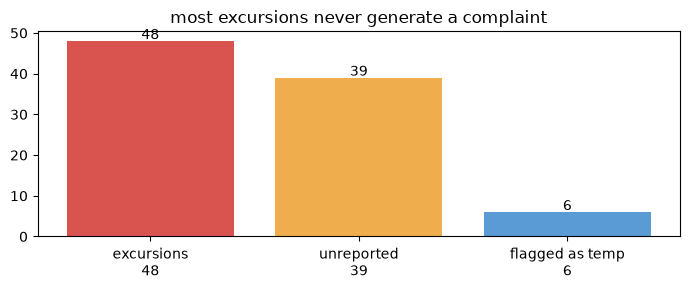

In [19]:
fig, ax = plt.subplots(figsize=(7,3))
vals=[len(exc), (~exc.issue).sum(), (exc.issue_type=='temp_concern').sum()]
ax.bar([f"excursions\n{vals[0]}", f"unreported\n{vals[1]}", f"flagged as temp\n{vals[2]}"],
       vals, color=["#d9534f","#f0ad4e","#5b9bd5"])
[ax.text(i,v+0.5,str(v),ha="center") for i,v in enumerate(vals)]
ax.set_title("most excursions never generate a complaint"); plt.tight_layout(); plt.show()

**Finding 2:** excursions are ~3.7× more likely to draw a complaint (solid, p≈0.008) — but
**81% of excursions reach the pharmacy with no complaint at all.** pharmacies are precise
when they flag temp (100% real) but catch only ~1 in 8. so "no news" has been *hiding* the
problem, not confirming it's fine. this is the entire case for sensor monitoring: we
literally cannot see ~80% of our cold-chain failures through complaints.

## 6. Finding 3 — late is hot

In [20]:
d = df.dropna(subset=["actual_delivery"]).copy()   # drop the 2 in-transit
d["late_min"] = (pd.to_datetime(d.actual_delivery,errors="coerce")
                 - pd.to_datetime(d.planned_delivery,errors="coerce")).dt.total_seconds()/60
print("on-time: %.0f%% | median lateness %.0f min" % ((d.late_min<=0).mean()*100, d.late_min.median()))
if HAVE_SCIPY:
    print("corr(lateness, exc minutes): rho=%.2f p=%.4f" % stats.spearmanr(d.late_min, d.excursion_minutes))
print("excursion rate >3h late: %.0f%%  vs  <=1h late: %.0f%%"
      % (d[d.late_min>180].has_exc.mean()*100, d[d.late_min<=60].has_exc.mean()*100))

on-time: 25% | median lateness 81 min
corr(lateness, exc minutes): rho=0.15 p=0.0145
excursion rate >3h late: 31%  vs  <=1h late: 14%


**Finding 3:** only ~a quarter arrive on time, and lateness tracks with excursions —
>3h late roughly doubles the excursion rate. speed and temperature are the same problem;
the longer it sits in the network the more heat/cold it eats. transit time on bad lanes is
a direct cold-chain lever.

## 7. stuff I wasn't looking for but couldn't unsee

three tidbits that fell out of the exploration:

In [21]:
# (a) THE WEIRD ONE: refrigerated product isn't just overheating — it's FREEZING.
r = df[df.temp_class=="2-8C"]; rex = r[r.has_exc]
print("of %d refrigerated (2-8C) excursions:" % len(rex))
print("  too HOT (max>8):        %d" % (rex.max_temp_c>8).sum())
print("  too COLD (min<2):       %d" % (rex.min_temp_c<2).sum())
print("  actually FROZE (min<0): %d  (down to %.1f C)" % ((rex.min_temp_c<0).sum(), rex.min_temp_c.min()))
froze = r[r.min_temp_c<0]
print("  ...and %d of those %d frozen-solid shipments drew NO complaint" % ((~froze.issue).sum(), len(froze)))

of 28 refrigerated (2-8C) excursions:
  too HOT (max>8):        24
  too COLD (min<2):       13
  actually FROZE (min<0): 4  (down to -0.7 C)
  ...and 3 of those 4 frozen-solid shipments drew NO complaint


**(a) Our refrigerated cold chain is failing by being too *cold*, not just too hot.** Almost
half of 2–8 °C excursions dipped below the floor and **4 shipments literally froze** (down
to −0.7 °C). that matters because for a lot of biologics/vaccines, freezing is *irreversible*
— worse than a mild warm spike — and it usually comes from over-packing dry ice or gel
packs, i.e. an over-correction. and 3 of the 4 frozen ones nobody flagged. this is the kind
of thing you'd never catch without the sensor, and ops probably isn't even watching the
cold side.

In [22]:
# (b) I assumed warmer spring months = more excursions. checked. nope.
df["month"] = pd.to_datetime(df.ship_date, errors="coerce").dt.to_period("M").astype(str)
df.groupby("month").agg(n=("has_exc","size"), exc_rate=("has_exc","mean"),
                        avg_max_temp=("max_temp_c","mean")).assign(
                        exc_rate=lambda x:(x.exc_rate*100).round(0)).round(1)

,n,exc_rate,avg_max_temp
month,,,
2026-01,10,0.0,14.5
2026-02,87,20.0,9.0
2026-03,95,20.0,10.1
2026-04,60,20.0,6.6


**(b) It's not seasonal.** I figured excursions would climb as spring warmed up. they
don't — the rate sits flat at ~20% Feb→Apr while average max temp actually *falls*. so this
isn't weather we ride out; it's structural (= carrier). good, because structural is fixable.

In [23]:
# (c) how concentrated is the damage?
s = df.excursion_minutes.sort_values(ascending=False).reset_index(drop=True)
print("top 5 shipments  = %.0f%% of ALL out-of-temp time" % (s[:5].sum()/s.sum()*100))
print("top 10 shipments = %.0f%% of ALL out-of-temp time" % (s[:10].sum()/s.sum()*100))
print("and only %d of %d shipments had any excursion at all" % (df.has_exc.sum(), len(df)))

top 5 shipments  = 30% of ALL out-of-temp time
top 10 shipments = 48% of ALL out-of-temp time
and only 48 of 252 shipments had any excursion at all


**(c) The damage is wildly concentrated** — 10 shipments account for ~half of all the
out-of-temp time in the quarter. this is good news: it means the problem is a short,
fixable list, not a thousand small leaks.

*(also poked at day-of-week: Friday shipments excurse 30% vs ~15% midweek, and it's not an
OnTrac artifact — FedEx alone is 25% on Fridays vs 12% otherwise. smells like weekend dwell:
ship Friday, sit in the network through the weekend, eat more thermal exposure. didn't
chase it further but it's a real pattern.)*

## 8. ok, but how much is this actually costing? (rough $)

The file has no product values, so this is an *estimate* with assumptions spelled out and
left as knobs — point is the order of magnitude and where it's concentrated, not a precise
number. swap in real numbers and it updates.

In [24]:
# ---- ASSUMPTIONS (edit these) ----
UNIT_VALUE = 2000     # $ value of product per shipment. specialty pharma midpoint; REPLACE with real AWP
P_WRITEOFF = {        # chance product is unusable, by how long it was out of temp
    "minor":  0.10,   # < 1 hr out
    "moder":  0.30,   # 1-4 hr
    "severe": 0.70,   # > 4 hr
}
span_days = (pd.to_datetime(df.ship_date).max() - pd.to_datetime(df.ship_date).min()).days
ANNUALIZE = 365 / span_days

def tier(m):
    return "minor" if m < 60 else ("moder" if m <= 240 else "severe")

exc = df[df.has_exc].copy()
exc["tier"] = exc.excursion_minutes.apply(tier)
exc["exp_loss"] = exc.tier.map(P_WRITEOFF) * UNIT_VALUE

print("excursions by severity:", exc.tier.value_counts().to_dict())
loss_90 = exc.exp_loss.sum()
print(f"\nestimated product loss, 90 days: ${loss_90:,.0f}")
print(f"annualized (x{ANNUALIZE:.1f}):        ${loss_90*ANNUALIZE:,.0f}/yr")
ot_loss = exc[exc.carrier=='OnTrac'].exp_loss.sum()
print(f"   of which OnTrac:            ${ot_loss*ANNUALIZE:,.0f}/yr ({ot_loss/loss_90*100:.0f}%)")

excursions by severity: {'moder': 27, 'severe': 20, 'minor': 1}

estimated product loss, 90 days: $44,400
annualized (x4.1):        $182,090/yr
   of which OnTrac:            $83,663/yr (46%)


In [25]:
# sensitivity — because UNIT_VALUE is the big unknown. (P_WRITEOFF held at base tiers)
base = exc.tier.map(P_WRITEOFF).sum()   # expected # of write-offs per 90d
print("expected write-offs / yr: %.0f\n" % (base*ANNUALIZE))
print("annual $ loss if a unit is worth...")
for v in [500, 1000, 2000, 5000, 10000]:
    print(f"  ${v:>6,}/unit  ->  ${base*v*ANNUALIZE:>12,.0f}/yr")

expected write-offs / yr: 91

annual $ loss if a unit is worth...
  $   500/unit  ->  $      45,522/yr
  $ 1,000/unit  ->  $      91,045/yr
  $ 2,000/unit  ->  $     182,090/yr
  $ 5,000/unit  ->  $     455,225/yr
  $10,000/unit  ->  $     910,449/yr


**Estimated ~$180k/yr in product write-offs (base case, $2k/unit), and that's the
conservative read** — it ignores reship costs, expedited replacement, staff time, and the
compliance/patient exposure of a degraded drug actually being dispensed. **OnTrac is
roughly half of it.** If MercyHealth's units run closer to $5–10k (very normal for
specialty/biologic), this is a **half-million-dollar-plus** annual line item. The exact
figure hinges on two numbers we don't have — which is the whole point of the question
below.

## 9. what I genuinely can't see in this data — so the first question I'd ask

Everything above measures **exposure**: minutes out of temp, counts, complaints. none of it
measures **consequence**. for any given shipment this file never tells me:

- what happened to the product — dispensed, quarantined, or destroyed?
- what a unit is actually worth (I had to assume $2k); and
- whether a patient was affected.

that's exactly why I can rank the risk confidently (OnTrac frozen, top of the list) but
have to *guess* at the dollars. so before building anything fancier, the one thing I'd want:

> **When a shipment goes out of temperature, what actually happens to it downstream —
> released, quarantined, or written off — and what is that unit worth?**

asking that first because it's the difference between optimizing a proxy and optimizing the
real loss. right now we'd triage by minutes-out-of-temp; with disposition + unit cost we'd
triage by dollars and patient risk, and we'd finally know which of these 48 excursions
actually cost us anything.

## where MercyHealth is losing money / risking compliance — and where it isn't

**Paying attention to:**
1. **OnTrac, especially frozen.** 15% of volume → 60% of out-of-temp time, a third of
   complaints, ~half the estimated loss (~$80k+/yr). OnTrac frozen runs ~9h out of range.
   *(the "West Coast" and "Sunrise service" stories are both just OnTrac in disguise.)*
2. **The blind spot.** 81% of excursions never get reported, so we can't run cold-chain off
   complaints — the sensor data has to be the monitor.
3. **Refrigerated product freezing.** an invisible, possibly-irreversible failure mode on
   the *cold* side that nobody's watching — worth a packaging/coolant look.
4. **Late = hot, and Fridays.** transit time is a real lever; weekend dwell looks real.

**Where we're *not* losing money (leave it alone):** FedEx and UPS on refrigerated and
room-temp lanes are performing well. CRT basically takes care of itself. no need to spend
attention there right now.

**Bottom line:** the losses aren't spread across the network — they're concentrated in a
short, fixable list (10 shipments = half the out-of-temp time), and mostly behind one
carrier. that's a good problem to have.